# Präsentation — DSP-Grafiken

Grafiken für den Problemstellungs-/DSP-Teil der Präsentation:

1. **Problemstellung**: Mixture-Wellenform + Spektrogramme Vollband vs. Bandbegrenzt.
2. **Stems**: Zeitbereichs-Wellenformen der 4 Stems + Mixture (3 Beispiele) und die
   zugehörigen STFT-Spektrogramme nebeneinander.
3. **STFT-Round-Trip**: Rekonstruktionsfehler mit/ohne Center-Padding (wie `01_dsp`).

Auswahl-Zellen (`>>> ... <<<`) vor dem Export anpassen; `SAVE=True` schreibt die PNGs
nach `praesentation/plots/`.

In [1]:
import os
# MÜSSEN vor dem TensorFlow-Import gesetzt sein (oneDNN-Crash-Fix + leise Logs).
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from bwe import config as cfg
from bwe.dsp.stft import stft, istft
from bwe.dsp.bandlimit import bandlimit
from bwe.data.loaders import load_demo
from bwe.eval.plots import show_spec

# >>> Export-Ziel für die Präsentations-Dateien <<<
SAVE   = True                # False = nur anzeigen, nichts speichern
ASSETS = Path(os.environ.get("BWE_PRAES_DIR",
    r"C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation"))

def save_fig(fig, name, subdir="plots"):
    """Figur als PNG in den Präsentations-Ordner schreiben (nur wenn SAVE=True)."""
    if SAVE:
        p = ASSETS / subdir / name
        p.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(p, dpi=200, bbox_inches="tight")
        print("  gespeichert:", p)

print(cfg.summary())

SR=32000 Hz | N_FFT=1024 HOP=256 | 31.250 Hz/Bin
Bins: full=513 net=512 | Cutoffs=(8000,) Hz | Standard 8000 Hz -> Bin 256
Copy-Up-Quellband = Bins 128..256
Segment: 128 Frames = 33536 Samples (~1.048 s)
DATA_ROOT=C:\Users\danyr\bwe_data\musdb18hq_32k


## 1. Problemstellung

Oben die Mixture-Wellenform über die volle Breite, unten Vollband- und bandbegrenztes
Spektrogramm nebeneinander — *„oberhalb von 8 kHz fehlt alles"*.

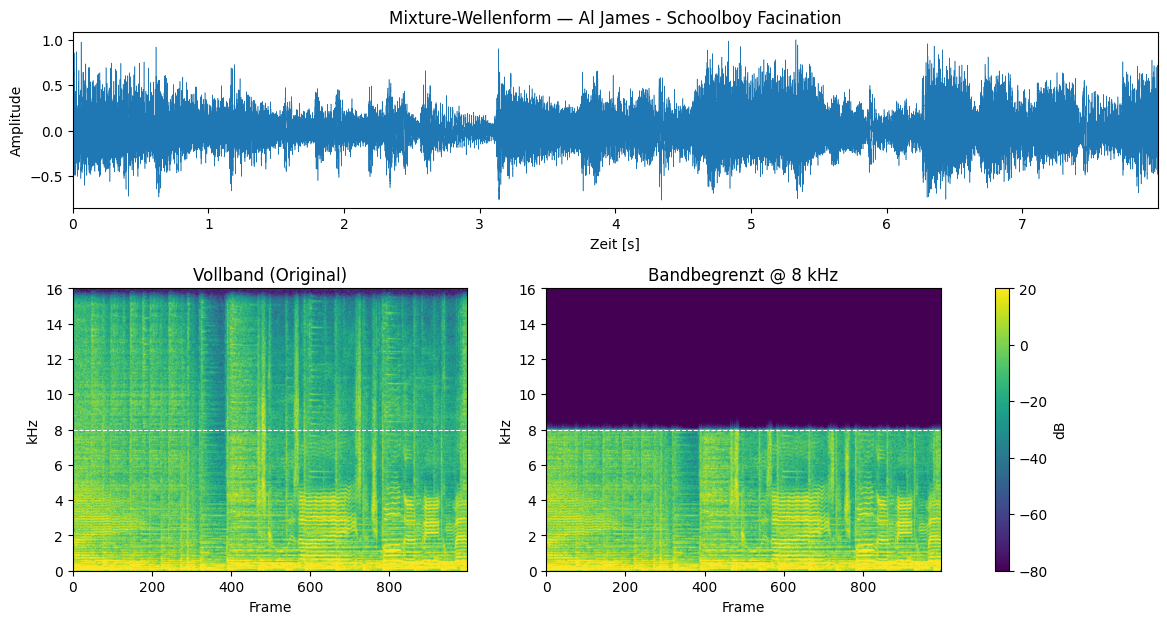

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\problemstellung.png


In [2]:
# >>> Auswahl <<<
SPLIT, INDEX, OFFSET, SECONDS = "test", 0, 30.0, 8.0

name, wave = load_demo(SPLIT, INDEX, seconds=SECONDS, offset=OFFSET)
band = bandlimit(wave)

fig = plt.figure(figsize=(14, 7))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.6], hspace=0.35)
ax_w = fig.add_subplot(gs[0, :])
t = np.arange(len(wave)) / cfg.SR
ax_w.plot(t, wave, lw=0.4, color="C0")
ax_w.set_xlim(0, t[-1])
ax_w.set_xlabel("Zeit [s]"); ax_w.set_ylabel("Amplitude")
ax_w.set_title(f"Mixture-Wellenform — {name}")

ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1], sharey=ax1)
show_spec(ax1, stft(wave), "Vollband (Original)")
im = show_spec(ax2, stft(band), "Bandbegrenzt @ 8 kHz")
fig.colorbar(im, ax=[ax1, ax2], label="dB")
plt.show()
save_fig(fig, "problemstellung.png")

## 2. Stems & Mixture — Wellenformen

Die vier MUSDB18-Stems (vocals, drums, bass, other) und die Mixture (= Summe)
untereinander, gemeinsam auf den Mixture-Spitzenpegel normiert (relative Pegel bleiben
echt). Drei Beispiele.

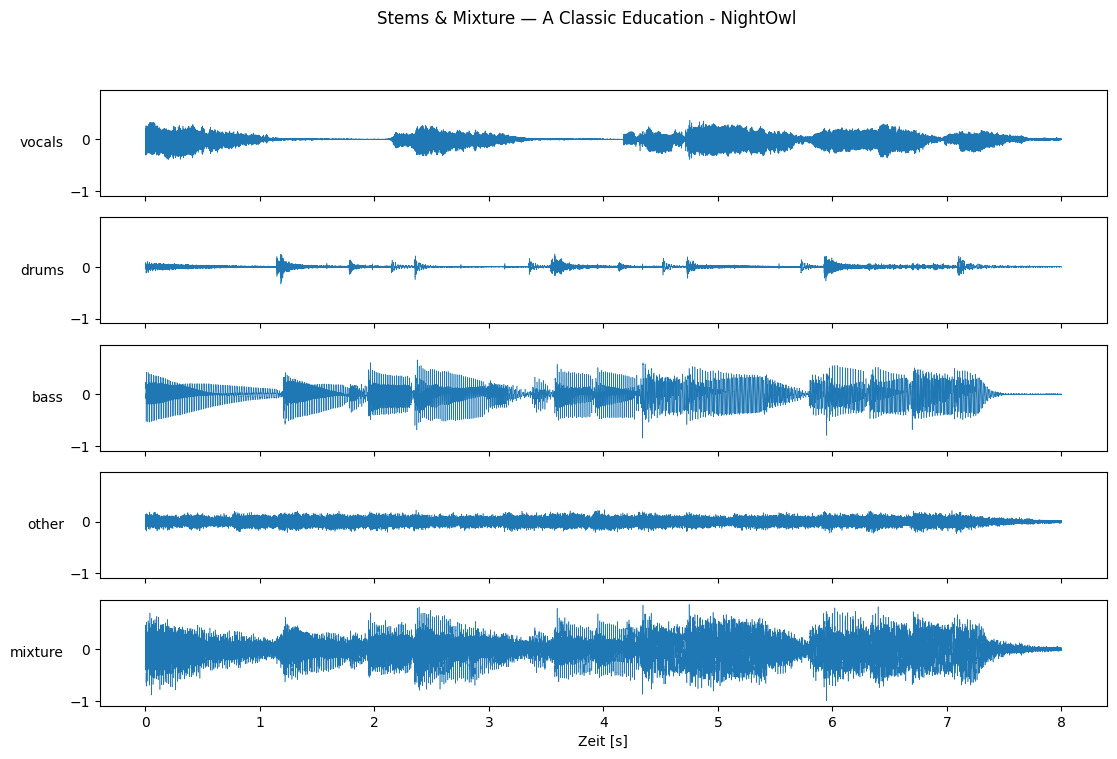

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\stems_wellenform_train00.png


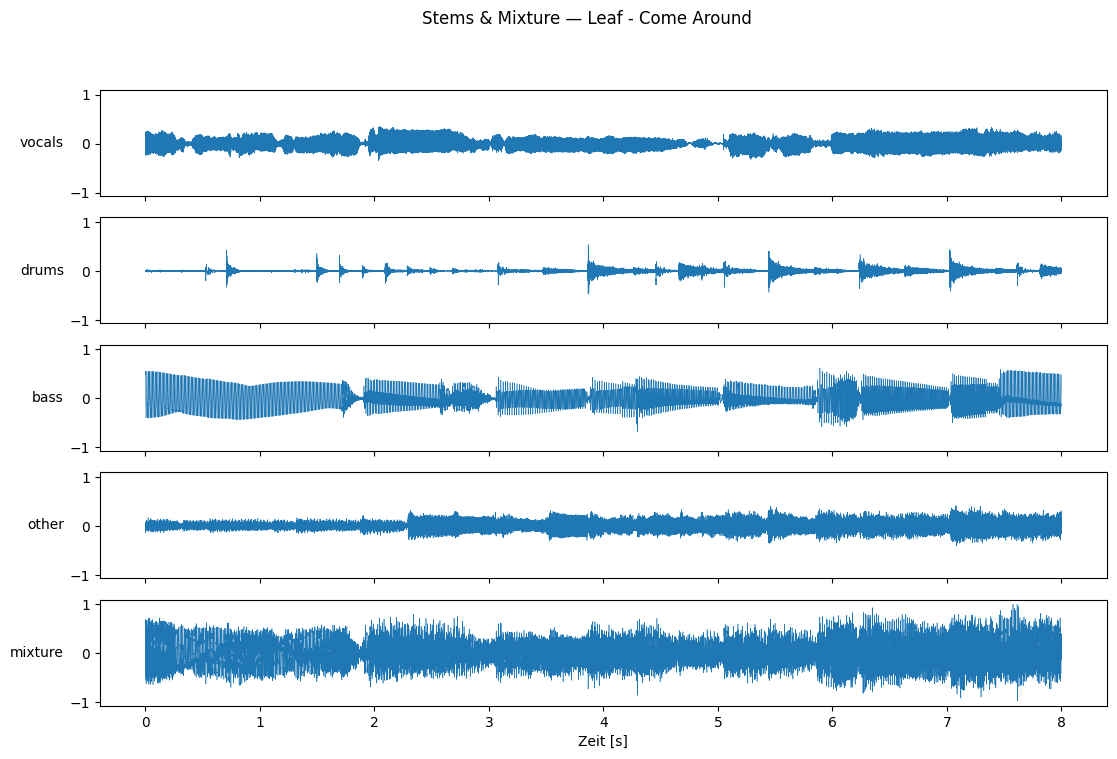

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\stems_wellenform_train40.png


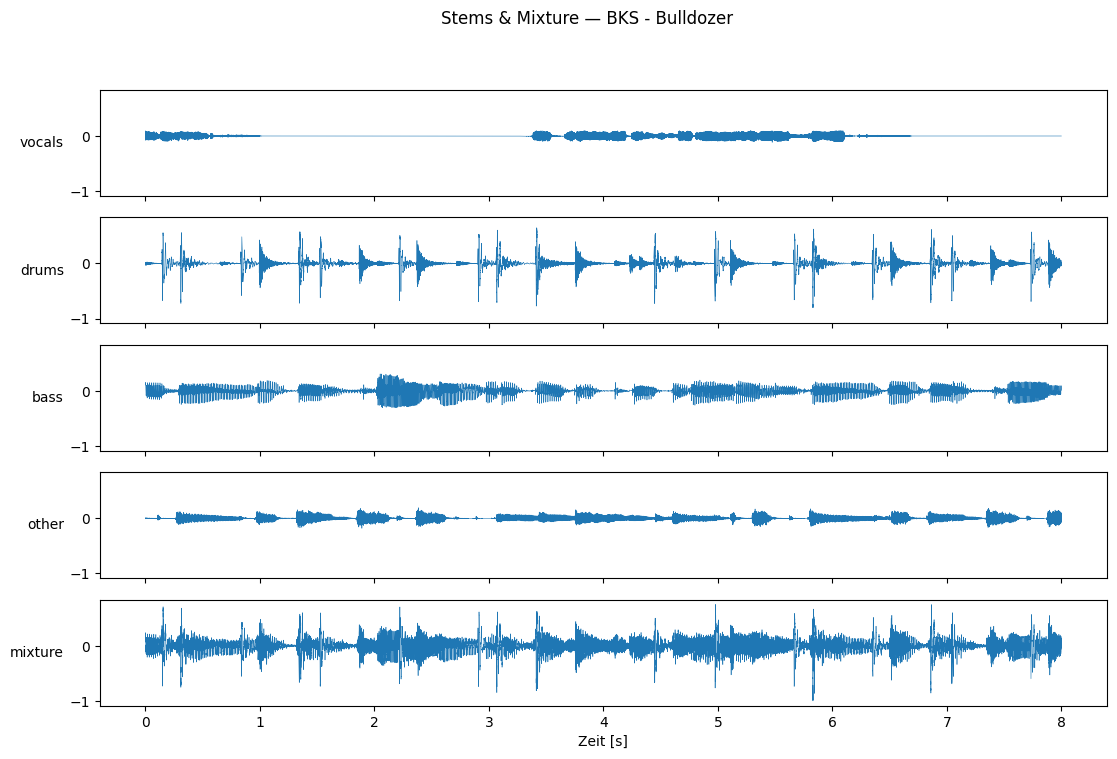

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\stems_wellenform_test05.png


In [3]:
# >>> Drei Beispiele: (split, index, offset_s, dauer_s) <<<
STEM_DEMOS = [
    ("train",  0, 30.0, 8.0),
    ("train", 40, 60.0, 8.0),
    ("test",   5, 30.0, 8.0),
]


def stem_waves(split, index, offset, seconds):
    """Alle 4 Stems + Mixture, gemeinsam auf den Mixture-Spitzenpegel normiert."""
    parts = {}
    for s in cfg.STEMS:
        name, w = load_demo(split, index, seconds=seconds, offset=offset,
                            stems=s, normalize=False)
        parts[s] = w
    mix = sum(parts.values())
    norm = max(1e-9, float(np.max(np.abs(mix))))
    waves = {k: (v / norm).astype(np.float32) for k, v in parts.items()}
    waves["mixture"] = (mix / norm).astype(np.float32)
    return name, waves


for split, index, offset, seconds in STEM_DEMOS:
    name, waves = stem_waves(split, index, offset, seconds)
    t = np.arange(len(waves["mixture"])) / cfg.SR
    fig, axes = plt.subplots(5, 1, figsize=(13, 8), sharex=True, sharey=True)
    for ax, (lbl, w) in zip(axes, waves.items()):
        ax.plot(t, w, lw=0.4)
        ax.set_ylabel(lbl, rotation=0, ha="right", va="center")
    axes[-1].set_xlabel("Zeit [s]")
    fig.suptitle(f"Stems & Mixture — {name}")
    plt.show()
    save_fig(fig, f"stems_wellenform_{split}{index:02d}.png")

### Dazu die STFT-Spektrogramme

Dieselben fünf Signale als Spektrogramme nebeneinander — zeigt, *wo* jeder Stem
spektral lebt (Bass unten, Becken/Hi-Hats oben).

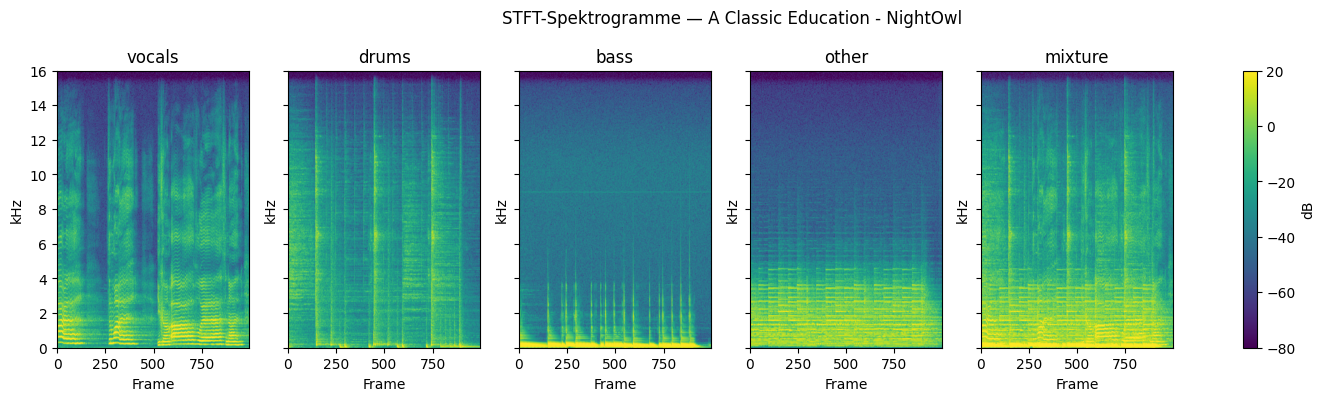

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\stems_spektrogramme_train00.png


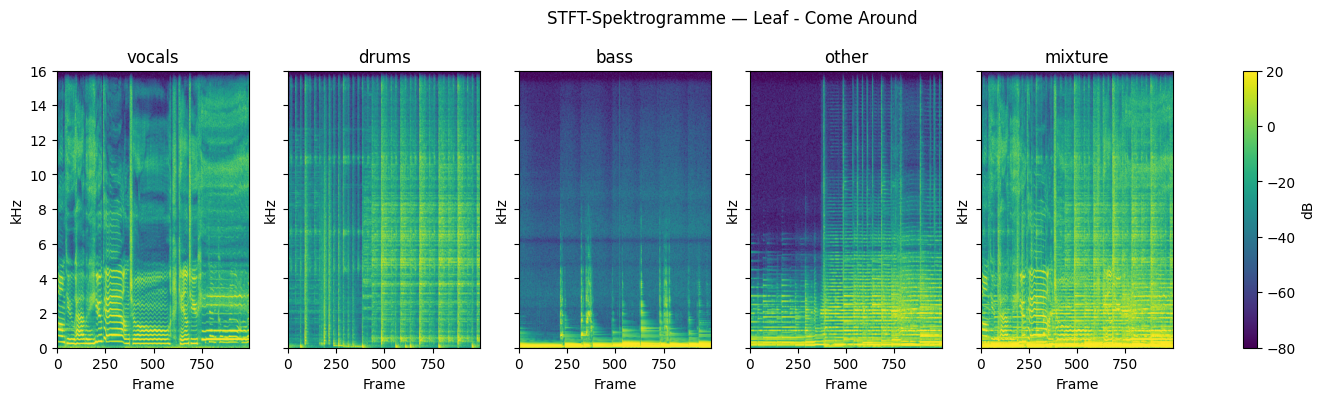

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\stems_spektrogramme_train40.png


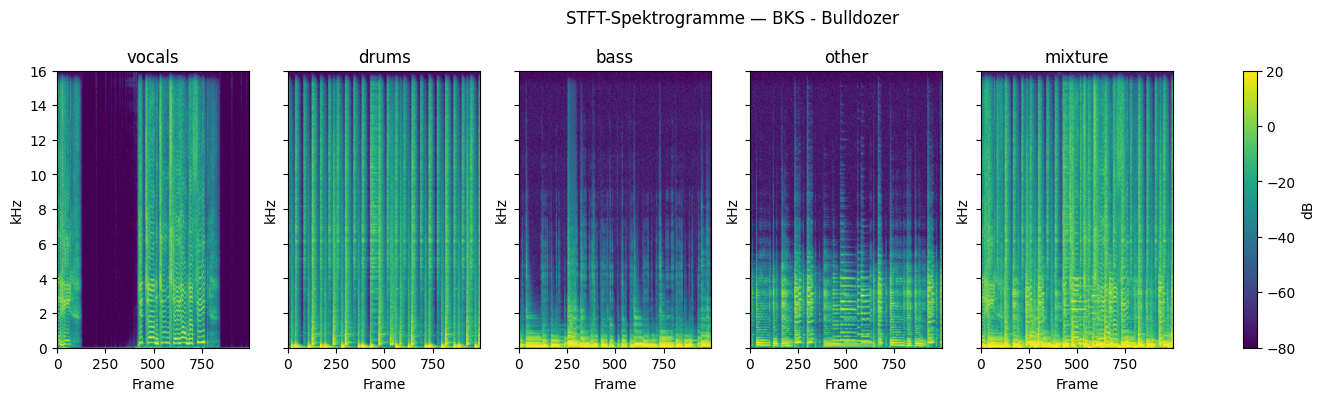

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\stems_spektrogramme_test05.png


In [4]:
for split, index, offset, seconds in STEM_DEMOS:
    name, waves = stem_waves(split, index, offset, seconds)
    fig, axes = plt.subplots(1, 5, figsize=(18, 3.6), sharey=True)
    for ax, (lbl, w) in zip(axes, waves.items()):
        im = show_spec(ax, stft(w), lbl, draw_cutoff=False)
    fig.colorbar(im, ax=list(axes), label="dB")
    fig.suptitle(f"STFT-Spektrogramme — {name}", y=1.05)
    plt.show()
    save_fig(fig, f"stems_spektrogramme_{split}{index:02d}.png")

## 3. STFT-Round-Trip

`istft(stft(x)) ≈ x` — im Inneren ~1e-7, nur die ersten/letzten Frames haben durch die
unvollständige Overlap-Add sichtbare Fehler. Mit `N_FFT`-Zero-Padding (= librosa
`center=True`, so macht es die Inferenz) ist auch der Rand exakt sauber.

max |Fehler| ohne Padding (innen): 2.3841858e-07
max |Fehler| mit Padding (gesamt): 2.3841858e-07


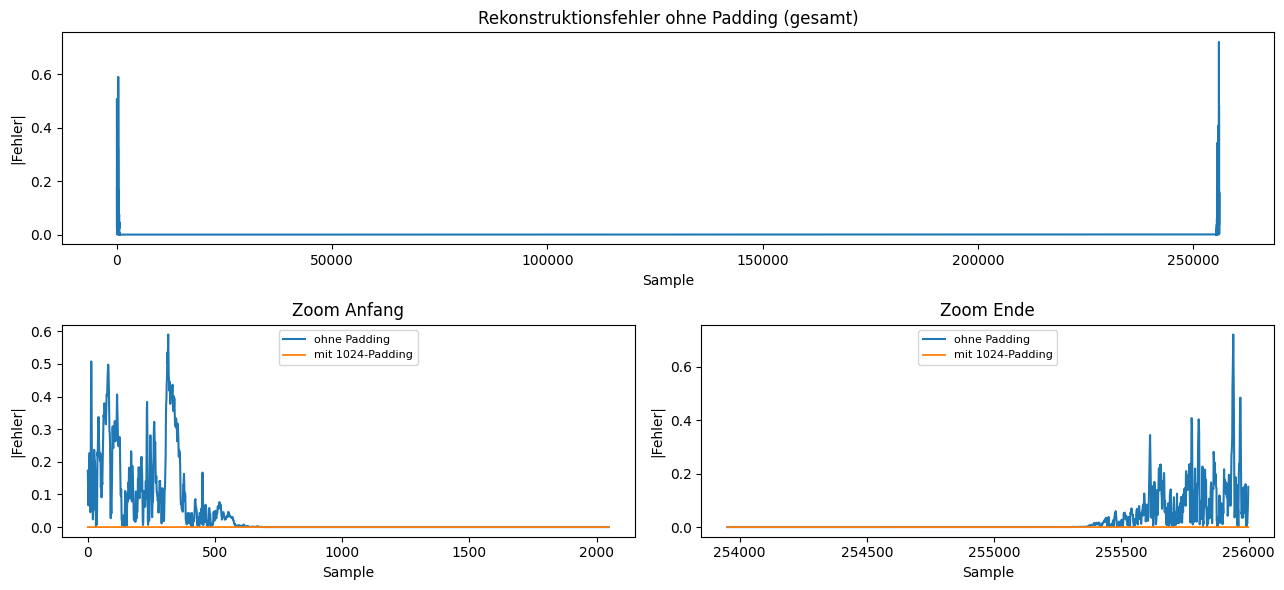

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\stft_roundtrip.png


In [5]:
def round_trip_err(x, pad):
    xp = np.pad(x, (pad, pad)).astype(np.float32)
    y = istft(stft(xp)).numpy()
    y = y[pad:pad + len(x)]
    return np.abs(y - x)


err = round_trip_err(wave, 0)                 # ohne Padding
err_pad = round_trip_err(wave, cfg.N_FFT)     # mit N_FFT-Padding
print("max |Fehler| ohne Padding (innen):", err[cfg.N_FFT:-cfg.N_FFT].max())
print("max |Fehler| mit Padding (gesamt):", err_pad.max())

zoom = 2 * cfg.N_FFT
n = len(wave)

fig = plt.figure(figsize=(13, 6))
gs = fig.add_gridspec(2, 2)
ax_full = fig.add_subplot(gs[0, :])
ax_start = fig.add_subplot(gs[1, 0])
ax_end = fig.add_subplot(gs[1, 1])

ax_full.plot(err, color="C0")
ax_full.set_title("Rekonstruktionsfehler ohne Padding (gesamt)")
ax_full.set_xlabel("Sample"); ax_full.set_ylabel("|Fehler|")

for ax, sl, x0, title in [(ax_start, slice(0, zoom), 0, "Zoom Anfang"),
                          (ax_end, slice(n - zoom, n), n - zoom, "Zoom Ende")]:
    xs = np.arange(x0, x0 + (sl.stop - sl.start))
    ax.plot(xs, err[sl], color="C0", label="ohne Padding")
    ax.plot(xs, err_pad[sl], color="C1", lw=1.3, label=f"mit {cfg.N_FFT}-Padding")
    ax.set_title(title); ax.set_xlabel("Sample"); ax.set_ylabel("|Fehler|")
    ax.legend(loc="upper center", fontsize=8)

plt.tight_layout(); plt.show()
save_fig(fig, "stft_roundtrip.png")